# Retrieving *Dataset*

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sameer9899","key":"d3a6cc912ae5e54755ff0d76b990e07b"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d mathurinache/citation-network-dataset


Dataset URL: https://www.kaggle.com/datasets/mathurinache/citation-network-dataset
License(s): CC-BY-NC-SA-4.0
100% 4.19G/4.19G [02:12<00:00, 33.3MB/s]
100% 4.19G/4.19G [02:12<00:00, 34.1MB/s]


In [ ]:
!unzip citation-network-dataset.zip


Archive:  citation-network-dataset.zip
  inflating: dblp.v12.json           


In [ ]:
import json
import re
import numpy as np
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import torch
import nltk
import re
import torch


In [ ]:
with open("dblp.v12.json", "r", encoding="utf8") as f:
    for i in range(10):
        line = f.readline()
        print(line[:400])  # Print only first 200 characters of each line


[

{"id":1091,"authors":[{"name":"Makoto Satoh","org":"Shinshu University","id":2312688602},{"name":"Ryo Muramatsu","org":"Shinshu University","id":2482909946},{"name":"Mizue Kayama","org":"Shinshu University","id":2128134587},{"name":"Kazunori Itoh","org":"Shinshu University","id":2101782692},{"name":"Masami Hashimoto","org":"Shinshu University","id":2114054191},{"name":"Makoto Otani","org":"Shinshu
,{"id":1388,"authors":[{"name":"Pranava K. Jha","id":2718958994}],"title":"Further Results on Independence in Direct-Product Graphs.","year":2000,"n_citation":1,"page_start":"","page_end":"","doc_type":"Journal","publisher":"","volume":"56","issue":"","doi":"","fos":[{"name":"Graph","w":0.0},{"name":"Discrete mathematics","w":0.45872},{"name":"Combinatorics","w":0.4515},{"name":"Direct product","w
,{"id":1674,"authors":[{"name":"G. Beale","org":"Archaeological Computing Research Group, University of Southampton, UK#TAB#","id":2103626414},{"name":"G. Earl","org":"Archaeological Computing Re

# Creation of batch json file with necessary data

In [ ]:

def stream_and_fix_malformed_batches(input_file, batch_size=10000, max_batches=None):
    current = ""
    brace_count = 0
    batch = []
    batch_count = 0
    paper_count = 0

    with open(input_file, 'r', encoding='utf8') as f:
        while True:
            char = f.read(1)
            if not char:
                break

            if char == '{':
                brace_count += 1
            if brace_count > 0:
                current += char
            if char == '}':
                brace_count -= 1
                if brace_count == 0:
                    try:
                        paper = json.loads(current)
                        if 'title' in paper and paper['title'].strip():
                            batch.append({
                                "id": paper.get("id", ""),
                                "title": paper["title"],
                                "abstract": paper.get("abstract", ""),
                                "references": paper.get("references", []),
                                "fos": [f["name"] for f in paper.get("fos", []) if "name" in f],
                                "url": "https://doi.org/" + paper.get("doi", "") if paper.get("doi") else ""
                            })
                            paper_count += 1
                            if paper_count % 5000 == 0:
                                print(f"Parsed {paper_count} papers so far")

                    except json.JSONDecodeError:
                        pass  # skip invalid
                    current = ""

            # Save each batch
            if len(batch) == batch_size:
                with open(f"batch_{batch_count}.json", "w", encoding="utf8") as out_file:
                    json.dump(batch, out_file, indent=2)
                print(f"Saved batch_{batch_count}.json with {len(batch)} papers.")
                batch = []
                batch_count += 1
                if max_batches and batch_count >= max_batches:
                    print("Max batch limit reached.")
                    break

    # Final save
    if batch:
        with open(f"batch_{batch_count}.json", "w", encoding="utf8") as out_file:
            json.dump(batch, out_file, indent=2)
        print(f"Saved final batch_{batch_count}.json with {len(batch)} papers.")

    print(f"\nDone. Total papers: {paper_count}, Total batches: {batch_count + 1}")


In [ ]:
stream_and_fix_malformed_batches("dblp.v12.json", batch_size=10000, max_batches=5)


Saved final batch_0.json with 1399 papers.

Done. Total papers: 1399, Total batches: 1


In [ ]:
with open("batch_0.json", "r", encoding="utf8") as f:
    for i in range(30):
        line = f.readline()
        print(line[:400])

[

  {

    "id": 1091,

    "title": "Preliminary Design of a Network Protocol Learning Tool Based on the Comprehension of High School Students: Design by an Empirical Study Using a Simple Mind Map",

    "abstract": "",

    "references": [

      2005687710,

      2018037215

    ],

    "fos": [

      "Telecommunications network",

      "Computer science",

      "Mind map",

      "Human\u2013computer interaction",

      "Multimedia",

      "Empirical research",

      "Comprehension",

      "Communications protocol"

    ],

    "url": "https://doi.org/10.1007/978-3-642-39476-8_19"

  },

  {

    "id": 1388,

    "title": "Further Results on Independence in Direct-Product Graphs.",

    "abstract": "",

    "references": [],

    "fos": [

      "Graph",

      "Discrete mathematics",

      "Combinatorics",



# Context Analysis

## Text Preprocessing Setup


In [ ]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re

stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def preprocess(text):
    words = re.findall(r'\b[a-z]+\b', text.lower())
    return ' '.join([stemmer.stem(w) for w in words if w not in stop_words])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
with open("batch_0.json", "r", encoding="utf8") as f:
    papers = json.load(f)

# Preprocess titles
titles = [preprocess(p['title']) for p in papers if p.get('title')]


## TF-IDF Vectorization and Normalization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

# TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(titles)

# Normalize to [0, 1]
dense_tfidf = tfidf_matrix.toarray()
scaler = MinMaxScaler()
normalized_tfidf = scaler.fit_transform(dense_tfidf)


## Grayscale Encoding

In [ ]:
import numpy as np

def encode_grayscale(vectors):
    grayscale_encoded = []
    for vec in vectors:
        binary_matrix = []
        for val in vec:
            index = int(val * 255)
            binary_str = format(index, '08b')
            binary_row = [int(bit) for bit in binary_str]
            binary_matrix.append(binary_row)
        grayscale_encoded.append(np.array(binary_matrix).T)
    return np.array(grayscale_encoded)

cnn_input = encode_grayscale(normalized_tfidf)
print("Grayscale CNN input shape:", cnn_input.shape)


Grayscale CNN input shape: (1399, 8, 2804)


In [ ]:
import torch
#convert to Pytorch Tensor
X = torch.tensor(cnn_input, dtype=torch.float32).unsqueeze(1)  # (N, 1, 8, num_features)


## CNN Model

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class RECSA_CNN(nn.Module):
    def __init__(self, input_width):
        super(RECSA_CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1)
        self.prelu1 = nn.PReLU()
        self.pool1 = nn.AdaptiveAvgPool2d((4, input_width // 2))

        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1)
        self.prelu2 = nn.PReLU()
        self.pool2 = nn.AdaptiveMaxPool2d((2, input_width // 4))

        self.fc1 = nn.Linear(64 * 2 * (input_width // 4), 256)
        self.fc2 = nn.Linear(256, 128)

    def forward(self, x):
        x = self.prelu1(self.conv1(x))
        x = self.pool1(x)
        x = self.prelu2(self.conv2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)  # output: (N, 128)


In [ ]:
# Instantiate the model
input_width = X.shape[3]
model = RECSA_CNN(input_width)
model.eval()

# Forward pass
with torch.no_grad():
    feature_vectors = model(X)  # shape: (N, 128)

print("Feature vectors shape:", feature_vectors.shape)


Feature vectors shape: torch.Size([1399, 128])


## Compute Similarity Matrix And Save Result

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

features_np = feature_vectors.numpy()
similarity_matrix = cosine_similarity(features_np)

print("Similarity matrix shape:", similarity_matrix.shape)  # should be (1399, 1399)


Similarity matrix shape: (1399, 1399)


In [ ]:
np.save("feature_vectors_batch0.npy", features_np)
np.save("similarity_matrix_batch0.npy", similarity_matrix)


# Citation network

## Build Citation Graph

In [ ]:
import json
import networkx as nx

with open("batch_0.json", "r", encoding="utf8") as f:
    papers = json.load(f)

# Build paper ID index map
paper_ids = [p["id"] for p in papers]
id_index_map = {pid: idx for idx, pid in enumerate(paper_ids)}

# Collect citation edges
edges = []
for paper in papers:
    src = paper.get("id")
    for ref in paper.get("references", []):
        if ref in id_index_map:
            edges.append((src, ref))

print(f"Total edges: {len(edges)}")

G = nx.DiGraph()
G.add_edges_from(edges)
G.add_nodes_from(paper_ids)


Total edges: 5


## FriendLink Similarity Score

In [ ]:
def friend_link_score(graph, u, v):
    if u == v:
        return 1.0

    common = set(graph.successors(u)).intersection(graph.predecessors(v))
    if not common:
        return 0.0

    deg_u = graph.out_degree(u)
    deg_v = graph.in_degree(v)
    return len(common) / (deg_u + deg_v + 1e-5)


##  Citation Similarity Matrix

In [ ]:
import numpy as np

N = len(paper_ids)
citation_matrix = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        u = paper_ids[i]
        v = paper_ids[j]
        citation_matrix[i][j] = friend_link_score(G, u, v)

print("Citation similarity matrix shape:", citation_matrix.shape)
np.save("citation_similarity_matrix_batch0.npy", citation_matrix)


Citation similarity matrix shape: (1399, 1399)


# Field Of Study Analysis

## Extracting FOS From Dataset

In [ ]:
import numpy as np
import json

# Load papers
with open("batch_0.json", "r", encoding="utf8") as f:
    papers = json.load(f)

# Extract FOS lists
fos_list = [set(p.get("fos", [])) for p in papers]
N = len(papers)
fos_similarity_matrix = np.zeros((N, N))




## Jaccard Similarity

In [ ]:
def jaccard_similarity(a, b):
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


## FOS Similarity Matrix

In [ ]:
for i in range(N):
    for j in range(N):
        fos_similarity_matrix[i][j] = jaccard_similarity(fos_list[i], fos_list[j])

print("FOS similarity matrix shape:", fos_similarity_matrix.shape)
np.save("fos_similarity_matrix_batch0.npy", fos_similarity_matrix)


FOS similarity matrix shape: (1399, 1399)


# Fusing All Similarities

## Finding Best Parameters

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

context_matrix = np.load("similarity_matrix_batch0.npy")
citation_matrix = np.load("citation_similarity_matrix_batch0.npy")
fos_matrix = np.load("fos_similarity_matrix_batch0.npy")


with open("batch_0.json", "r", encoding="utf8") as f:
    fusion_papers = json.load(f)

paper_ids = [p["id"] for p in fusion_papers]
id_to_index = {pid: idx for idx, pid in enumerate(paper_ids)}
index_to_id = {idx: pid for pid, idx in id_to_index.items()}
references = {p["id"]: set(p.get("references", [])) for p in fusion_papers}



In [ ]:
def evaluate_precision(sim_matrix, k=5):
    precisions = []

    for i, paper in enumerate(fusion_papers):
        true_refs = references.get(paper["id"], set()) & set(id_to_index.keys())
        if not true_refs:
            continue

        sim_scores = sim_matrix[i]
        ranked_indices = np.argsort(-sim_scores)
        ranked_indices = [idx for idx in ranked_indices if idx != i][:k]
        retrieved = {index_to_id[idx] for idx in ranked_indices}

        tp = len(true_refs & retrieved)
        precision = tp / k
        precisions.append(precision)

    return round(np.mean(precisions), 4)


In [ ]:
results = []
ks = [0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
for alpha in ks:
    for beta in ks:
        gamma = 1 - alpha - beta
        if gamma < 0 or gamma > 1:
            continue

        fused = (
            alpha * context_matrix +
            beta * citation_matrix +
            gamma * fos_matrix
        )
        score = evaluate_precision(fused, k=5)
        results.append((round(alpha,2), round(beta,2), round(gamma,2), score))


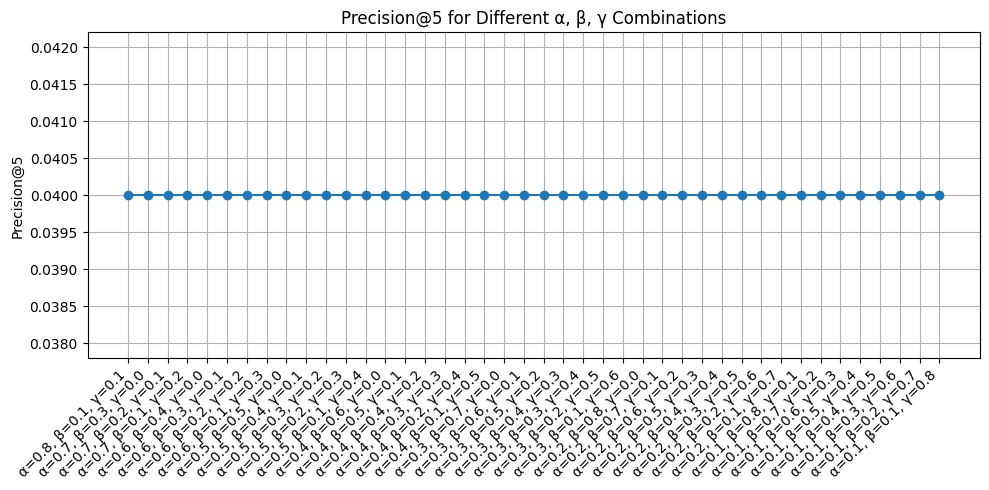

Best combo: α=0.8, β=0.1, γ=0.1 → Precision@5 = 0.04


In [ ]:
results.sort(key=lambda x: -x[3])
alphas = [r[0] for r in results]
betas = [r[1] for r in results]
gammas = [r[2] for r in results]
scores = [r[3] for r in results]

plt.figure(figsize=(10, 5))
plt.plot(range(len(scores)), scores, marker='o')
plt.xticks(range(len(scores)), [f"α={a}, β={b}, γ={g}" for a, b, g in zip(alphas, betas, gammas)], rotation=45, ha='right')
plt.ylabel("Precision@5")
plt.title("Precision@5 for Different α, β, γ Combinations")
plt.grid(True)
plt.tight_layout()
plt.show()

# Show the best score
best_combo = results[0]
print(f"Best combo: α={best_combo[0]}, β={best_combo[1]}, γ={best_combo[2]} → Precision@5 = {best_combo[3]}")


## Fusing Similarities Using The Best Combos

In [ ]:
context_matrix = np.load("similarity_matrix_batch0.npy")
citation_matrix = np.load("citation_similarity_matrix_batch0.npy")
fos_matrix = np.load("fos_similarity_matrix_batch0.npy")

alpha = 0.8
beta = 0.1
gamma = 0.1


final_similarity = (
    alpha * context_matrix +
    beta * citation_matrix +
    gamma * fos_matrix
)

np.save("final_similarity_matrix_batch0.npy", final_similarity)
print("Fused final similarity matrix saved.")


Fused final similarity matrix saved.


# Testing

In [ ]:
import numpy as np
import json

# Load similarity matrix
similarity_matrix = np.load("final_similarity_matrix_batch0.npy")

# Load papers to get titles
with open("batch_0.json", "r", encoding="utf8") as f:
    papers = json.load(f)


In [ ]:
def get_top_k_similar(paper_idx, k=5):
    scores = similarity_matrix[paper_idx]
    top_k_indices = np.argsort(-scores)[:k+1]
    results = []

    query_fos = set(papers[paper_idx].get("fos", []))

    for idx in top_k_indices:
        if idx == paper_idx:
            continue

        paper = papers[idx]
        candidate_fos = set(paper.get("fos", []))
        shared_fos = list(query_fos & candidate_fos)

        results.append({
            "index": idx,
            "title": paper.get("title", "Unknown"),
            "score": round(scores[idx], 4),
            "fos": list(candidate_fos),
            "shared_fos": shared_fos
        })

    return results


In [ ]:
paper_index = 110
print("Query paper:")
print(papers[paper_index]["title"])
print("FOS:", papers[paper_index].get("fos", []))

print("\nTop related papers (with shared FOS):")
top_related = get_top_k_similar(paper_index, k=5)

for i, rec in enumerate(top_related, 1):
    print(f"\n{i}. [{rec['score']}] {rec['title']}")
    print(f"   FOS: {rec['fos']}")
    if rec["shared_fos"]:
        print(f"Shared FOS: {rec['shared_fos']}")
    else:
        print("No FOS overlap")


Query paper:
Social TV: Linking TV Content to Buzz and Sales
FOS: ['Social media', 'Advertising', 'Computer science', 'Singing', 'Word of mouth', 'Marketing buzz', 'Broadcast television systems']

Top related papers (with shared FOS):

1. [0.8162] Quality Assessment on User Generated Image for Mobile Search Application
   FOS: ['User-generated content', 'Social media', 'Quality Score', 'Computer science', 'Data mining', 'Mobile search', 'Image retrieval']
Shared FOS: ['Social media', 'Computer science']

2. [0.8148] Personalized Marketing Messages in an Online Banking Context: Does Anybody Notice?
   FOS: ['Marketing', 'Computer science', 'Online advertising', 'Advertising', 'Personalized marketing', 'Notice', 'Personalization', 'Internet privacy']
Shared FOS: ['Computer science', 'Advertising']

3. [0.8138] Epidemic intelligence: for the crowd, by the crowd
   FOS: ['Social media', 'Public health', 'Computer science', 'Disease', 'Data science', 'Computer security', 'Disease surveillan

# Analysis Across Different Metrics

/tmp/ipython-input-33-3644268164.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


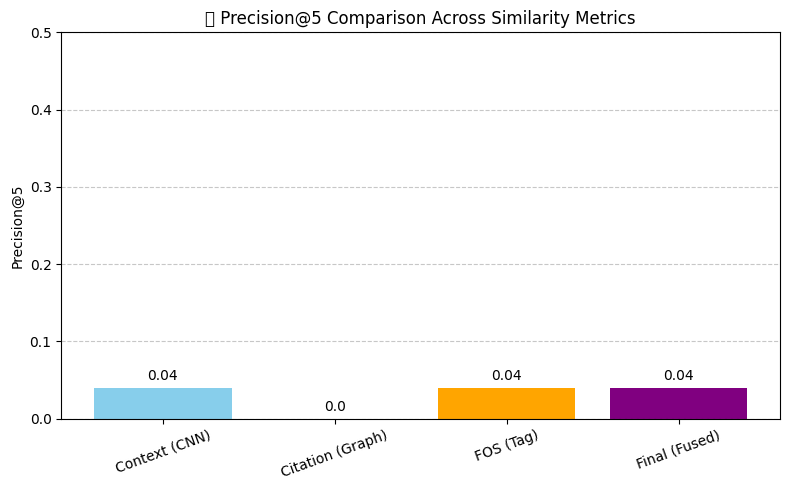

In [ ]:
precisions = {
    "Context (CNN)": evaluate_precision(context_matrix, k=5),
    "Citation (Graph)": evaluate_precision(citation_matrix, k=5),
    "FOS (Tag)": evaluate_precision(fos_matrix, k=5),
    "Final (Fused)": evaluate_precision(similarity_matrix, k=5)
}

# Plotting
import matplotlib.pyplot as plt

names = list(precisions.keys())
scores = list(precisions.values())

plt.figure(figsize=(8, 5))
plt.bar(names, scores, color=['skyblue', 'lightgreen', 'orange', 'purple'])
plt.title("📊 Precision@5 Comparison Across Similarity Metrics")
plt.ylabel("Precision@5")
plt.ylim(0, 0.5)
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, str(v), ha='center')
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
np.max(context_matrix), np.min(context_matrix), np.mean(context_matrix)


(np.float32(1.0000006), np.float32(0.99698764), np.float32(0.9992149))

/tmp/ipython-input-35-3350806909.py:30: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


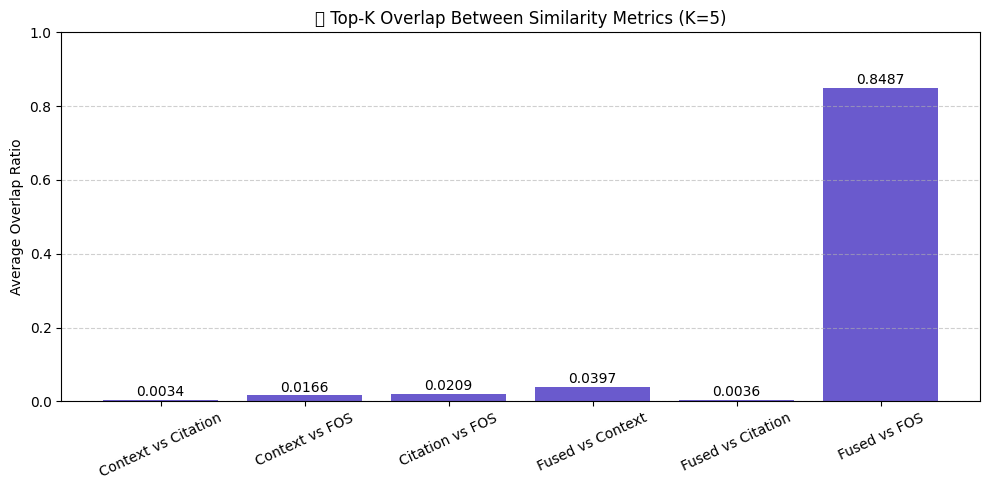

In [ ]:
def top_k_overlap(matrix_a, matrix_b, k=5):
    overlaps = []
    for i in range(len(papers)):
        a_top = set(np.argsort(-matrix_a[i])[:k+1]) - {i}
        b_top = set(np.argsort(-matrix_b[i])[:k+1]) - {i}
        overlap = len(a_top & b_top) / k
        overlaps.append(overlap)
    return round(np.mean(overlaps), 4)

# Overlap matrix
overlap_results = {
    "Context vs Citation": top_k_overlap(context_matrix, citation_matrix),
    "Context vs FOS": top_k_overlap(context_matrix, fos_matrix),
    "Citation vs FOS": top_k_overlap(citation_matrix, fos_matrix),
    "Fused vs Context": top_k_overlap(similarity_matrix, context_matrix),
    "Fused vs Citation": top_k_overlap(similarity_matrix, citation_matrix),
    "Fused vs FOS": top_k_overlap(similarity_matrix, fos_matrix)
}

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(overlap_results.keys(), overlap_results.values(), color='slateblue')
plt.title("🔁 Top-K Overlap Between Similarity Metrics (K=5)")
plt.ylabel("Average Overlap Ratio")
plt.ylim(0, 1)
plt.xticks(rotation=25)
for i, v in enumerate(overlap_results.values()):
    plt.text(i, v + 0.01, str(v), ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
